In [118]:
from nba_api.stats.endpoints import LeagueDashPlayerStats
import pandas as pd


In [120]:
stats = LeagueDashPlayerStats(season='2024-25')
df = stats.get_data_frames()[0]
df

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,1630639,A.J. Lawson,A.J.,1610612761,TOR,24.0,26,14,12,0.538,...,241,200,327,337,299,375,159,44,364,1
1,1631260,AJ Green,AJ,1610612749,MIL,25.0,73,44,29,0.603,...,99,498,290,214,62,247,281,44,225,1
2,1642358,AJ Johnson,AJ,1610612764,WAS,20.0,29,8,21,0.276,...,312,217,369,347,495,379,281,44,372,2
3,203932,Aaron Gordon,Aaron,1610612743,DEN,29.0,51,33,18,0.647,...,451,301,107,139,41,183,134,44,181,1
4,1628988,Aaron Holiday,Aaron,1610612745,HOU,28.0,62,39,23,0.629,...,224,259,292,292,115,322,281,44,315,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,203897,Zach LaVine,Zach,1610612758,SAC,30.0,74,32,42,0.432,...,501,418,46,12,414,40,93,44,23,2
565,1630192,Zeke Nnaji,Zeke,1610612743,DEN,24.0,57,36,21,0.632,...,254,252,327,365,323,343,281,44,357,1
566,1630533,Ziaire Williams,Ziaire,1610612751,BKN,23.0,63,22,41,0.349,...,458,476,142,178,551,189,159,44,184,1
567,1629627,Zion Williamson,Zion,1610612740,NOP,24.0,30,10,20,0.333,...,536,301,80,141,369,180,77,15,190,1


In [121]:
df[["PLAYER_NAME", "PTS"]].sort_values(by = "PTS", ascending = False).head(20)

,PLAYER_NAME,PTS
490,Shai Gilgeous-Alexander,2484
29,Anthony Edwards,2177
423,Nikola Jokić,2071
180,Giannis Antetokounmpo,2036
263,Jayson Tatum,1932
141,Devin Booker,1923
523,Trae Young,1841
540,Tyler Herro,1840
69,Cade Cunningham,1830
241,James Harden,1802


In [122]:
import matplotlib.pyplot as plt

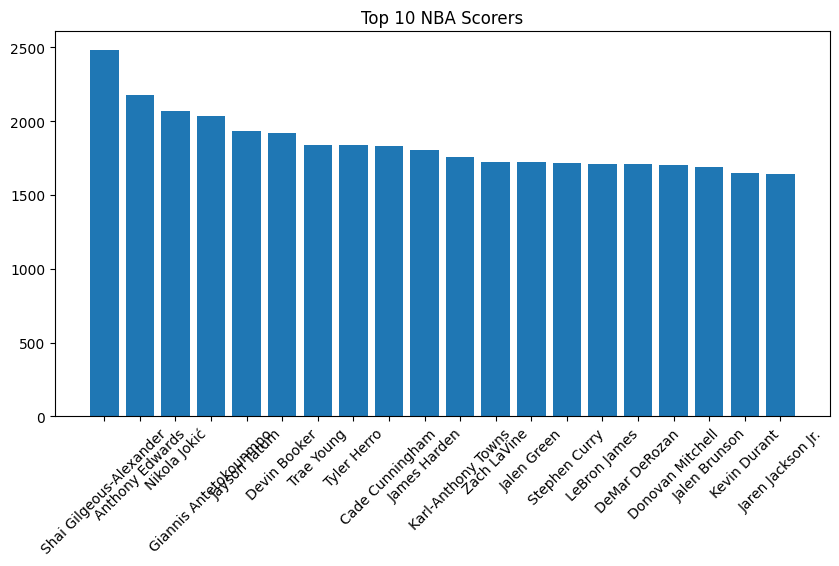

In [123]:
t10 = df[["PLAYER_NAME", "PTS"]].sort_values(by = "PTS", ascending = False).head(20)
plt.figure(figsize = (10, 5))
plt.bar(t10["PLAYER_NAME"], t10["PTS"])
plt.xticks(rotation = 45)
plt.title("Top 10 NBA Scorers")
plt.show()

In [124]:
seasons = ["2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]

all_data = []

for season in seasons:
    print(f"Downloading {season}")
    stats = LeagueDashPlayerStats(season=season)
    season_df = stats.get_data_frames()[0]
    season_df["SEASON"] = season
    all_data.append(season_df)

In [92]:
master = pd.concat(all_data, ignore_index=True)
master.shape
master.to_csv("../data.nba_stats.csv", index = False)

In [125]:
master.columns.to_list
master = master.sort_values(["PLAYER_ID", "SEASON"])
master["NEXT_PTS"] = (master.groupby("PLAYER_ID")["PTS"].shift(-1))

#remove nulls
master = master.dropna(subset=["NEXT_PTS"])

#remove players that played almost no minutes
master = master[master["MIN"] > 500]

master[['PLAYER_NAME','SEASON','PTS','NEXT_PTS']].head(20)


,PLAYER_NAME,SEASON,PTS,NEXT_PTS
333,LeBron James,2020-21,1126,1695.0
914,LeBron James,2021-22,1695,1590.0
1477,LeBron James,2022-23,1590,1822.0
2048,LeBron James,2023-24,1822,1710.0
66,Carmelo Anthony,2020-21,924,919.0
151,Dwight Howard,2020-21,482,372.0
18,Andre Iguodala,2020-21,275,124.0
560,Andre Iguodala,2021-22,124,17.0
504,Trevor Ariza,2020-21,282,96.0
77,Chris Paul,2020-21,1149,958.0


In [126]:
master["AGE_SQUARED"] = master["AGE"] ** 2
features = ["AGE", "AGE_SQUARED", "PTS", "AST", "REB", "MIN"]

X = master[features]
y = master["NEXT_PTS"]

X.head()
y.head()

333     1695.0
914     1590.0
1477    1822.0
2048    1710.0
66       919.0
Name: NEXT_PTS, dtype: float64

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [143]:
model = LinearRegression()

In [144]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.77, 0.01, 0.91,...,-0.73,-0.84, 4.09]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['AGE','AGE_SQUARED','PPG',...,'FG_PCT','FG3_PCT','FT_PCT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,11.51
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [145]:
predictions = model.predict(X_test)

In [146]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print(mae)

2.2215652095892384


In [147]:
master["PPG"] = master["PTS"]/master["GP"]
master[["PLAYER_NAME", "PTS", "GP", "PPG"]].head()

,PLAYER_NAME,PTS,GP,PPG
333,LeBron James,1126,45,25.022222
914,LeBron James,1695,56,30.267857
1477,LeBron James,1590,55,28.909091
18,Andre Iguodala,275,63,4.365079
77,Chris Paul,1149,70,16.414286


In [148]:
master = master.sort_values(["PLAYER_ID", "SEASON"])
master["NEXT_PPG"] = master.groupby("PLAYER_ID")["PPG"].shift(-1)

In [149]:
#remove missing
training = master.dropna(subset=['NEXT_PPG'])

#features
features = [
    'AGE',
    'AGE_SQUARED',
    'PPG',
    'AST',
    'REB',
    'MIN',
    'FG_PCT',
    'FG3_PCT',
    'FT_PCT'
]

X = training[features]
y = training["NEXT_PPG"]

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [151]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [152]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
mae

2.559432278713592

In [153]:
master[['PLAYER_NAME','PPG', "SEASON", 'NEXT_PPG']].head(40)

,PLAYER_NAME,PPG,SEASON,NEXT_PPG
333,LeBron James,25.022222,2020-21,30.267857
914,LeBron James,30.267857,2021-22,28.909091
1477,LeBron James,28.909091,2022-23,NaN
18,Andre Iguodala,4.365079,2020-21,NaN
77,Chris Paul,16.414286,2020-21,14.738462
627,Chris Paul,14.738462,2021-22,13.881356
1215,Chris Paul,13.881356,2022-23,NaN
449,Rudy Gay,11.365079,2020-21,NaN
324,Kyle Lowry,17.195652,2020-21,13.396825
904,Kyle Lowry,13.396825,2021-22,11.181818


In [155]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators = 500, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [156]:
rf_predictions = rf.predict(X_test)

In [157]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mae

2.368579482718208

In [158]:
import pandas as pd

importance = pd.DataFrame({"Feature": features, "Importance": rf.feature_importances_})
importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
2,PPG,0.850469
4,REB,0.022527
3,AST,0.022495
8,FT_PCT,0.022208
6,FG_PCT,0.020622
7,FG3_PCT,0.018441
5,MIN,0.018275
1,AGE_SQUARED,0.012716
0,AGE,0.012248


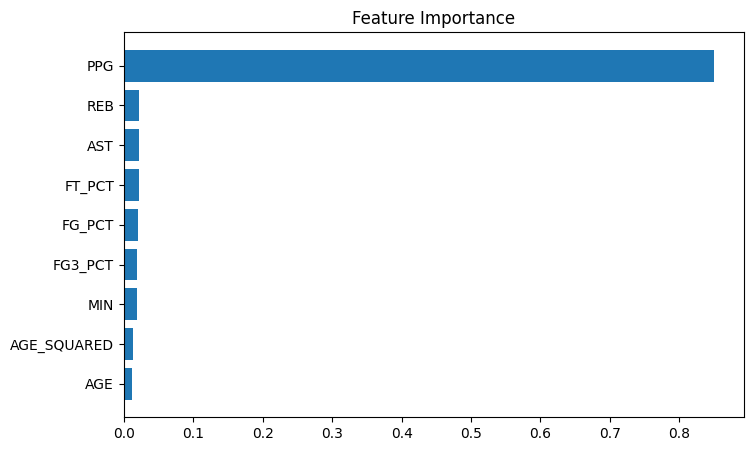

In [159]:
import matplotlib.pyplot as plt

importance = importance.sort_values(
    by='Importance'
)

plt.figure(figsize=(8,5))
plt.barh(
    importance['Feature'],
    importance['Importance']
)
plt.title("Feature Importance")
plt.show()

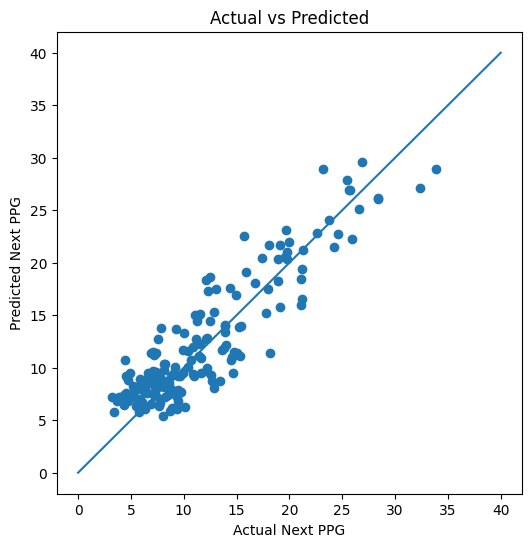

In [113]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Next PPG")
plt.ylabel("Predicted Next PPG")
plt.title("Actual vs Predicted")

plt.plot([0,40], [0,40])

plt.show()